In [4]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf

In [5]:
import os
os.chdir('/Users/gemie/orie3120proj/')
con = duckdb.connect()
zones = pd.read_csv("taxi_zone_lookup.csv")

In [6]:
new = con.sql(""" SELECT
    FLOOR(trip_time / 60) AS trip_duration_min,
    AVG(driver_pay) AS avg_driver_pay,
    COUNT(*) AS n
FROM read_parquet(['2024/*.parquet', '2025/*.parquet'])
WHERE (trip_time >= 120) AND (trip_time <= 7200) AND (driver_pay > 5)
GROUP BY trip_duration_min
ORDER BY trip_duration_min;
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## Linearity w/ Driver Pay
* filtered out trip > 2 hours since focus is in the city driving.

Text(0, 0.5, 'driver_pay_avg')

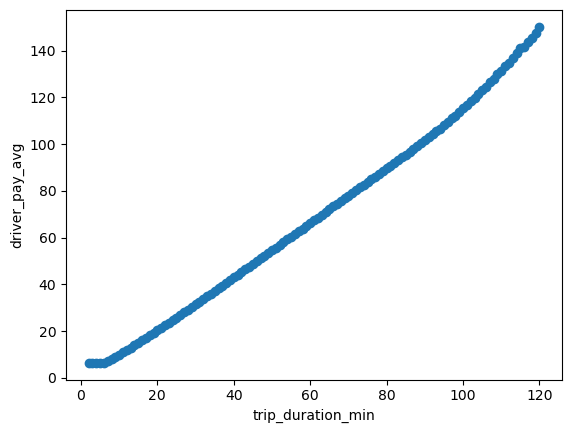

In [7]:
plt.scatter(new['trip_duration_min'] , new['avg_driver_pay'])
plt.xlabel("trip_duration_min")
plt.ylabel("driver_pay_avg")

In [5]:
all_vars = con.sql(""" SELECT PULocationID, z.Borough, FLOOR(trip_time / 60) AS trip_duration_min , driver_pay,
                    (CASE WHEN DOLocationID = 132 THEN 1 ELSE 0 END) as is_JFK,
                    (CASE WHEN DOLocationID = 138 THEN 1 ELSE 0 END) as is_LGA,
                    (CASE WHEN DOLocationID = 1 THEN 1 ELSE 0 END) as is_EWR,
                    HOUR(pickup_datetime) AS hour,
                    LOG(driver_pay) AS log_driver_pay
                FROM read_parquet(['2024/*.parquet', '2025/*.parquet']) a
                JOIN zones z ON a.PULocationID = z.LocationID
                WHERE (trip_time >= 120) AND (trip_time <= 7200) AND (driver_pay > 5)
                USING SAMPLE 2000000 ROWS
                 """).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [6]:
all_vars['log_driver_pay'] = np.log(all_vars['driver_pay'])
all_vars['log_duration']   = np.log(all_vars['trip_duration_min'])

model = smf.ols(
    formula='log_driver_pay ~ is_JFK + is_LGA + is_EWR + C(hour) + C(Borough) + log_duration',
    data=all_vars
).fit(cov_type='HC3')

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         log_driver_pay   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                 2.371e+05
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        19:14:14   Log-Likelihood:                -43431.
No. Observations:             1936071   AIC:                         8.693e+04
Df Residuals:                 1936039   BIC:                         8.733e+04
Df Model:                          31                                         
Covariance Type:                  HC3                                         
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       0.2813      0.002    180.464      0.000       0.278       0.284
C(hour)[T.1]                    0.0045      0.002      2.741      0.006       0.001       0.008
C(hour)[T.2]                    0.0158      0.002      8.617      0.000       0.012       0.019
C(hour)[T.3]                    0.0245      0.002     13.022      0.000       0.021       0.028
C(hour)[T.4]                    0.0578      0.002     30.540      0.000       0.054       0.062
C(hour)[T.5]                    0.0276      0.002     16.030      0.000       0.024       0.031
C(hour)[T.6]                   -0.0218      0.001    -14.631      0.000      -0.025      -0.019
C(hour)[T.7]                   -0.0661      0.001    -47.768      0.000      -0.069      -0.063
C(hour)[T.8]                   -0.0898      0.001    -67.341      0.000      -0.092      -0.087
C(hour)[T.9]                   -0.1028      0.001    -78.012      0.000      -0.105      -0.100
C(hour)[T.10]                  -0.1094      0.001    -82.439      0.000      -0.112      -0.107
C(hour)[T.11]                  -0.1162      0.001    -87.528      0.000      -0.119      -0.114
C(hour)[T.12]                  -0.1212      0.001    -91.560      0.000      -0.124      -0.119
C(hour)[T.13]                  -0.1237      0.001    -94.232      0.000      -0.126      -0.121
C(hour)[T.14]                  -0.1398      0.001   -108.121      0.000      -0.142      -0.137
C(hour)[T.15]                  -0.1474      0.001   -114.639      0.000      -0.150      -0.145
C(hour)[T.16]                  -0.1478      0.001   -115.393      0.000      -0.150      -0.145
C(hour)[T.17]                  -0.1340      0.001   -104.540      0.000      -0.137      -0.132
C(hour)[T.18]                  -0.1109      0.001    -86.155      0.000      -0.113      -0.108
C(hour)[T.19]                  -0.0915      0.001    -70.238      0.000      -0.094      -0.089
C(hour)[T.20]                  -0.0718      0.001    -54.353      0.000      -0.074      -0.069
C(hour)[T.21]                  -0.0454      0.001    -33.503      0.000      -0.048      -0.043
C(hour)[T.22]                  -0.0235      0.001    -17.064      0.000      -0.026      -0.021
C(hour)[T.23]                  -0.0120      0.001     -8.511      0.000      -0.015      -0.009
C(Borough)[T.Brooklyn]         -0.0501      0.001    -91.923      0.000      -0.051      -0.049
C(Borough)[T.Manhattan]         0.0126      0.001     22.339      0.000       0.011       0.014
C(Borough)[T.Queens]            0.0377      0.001     64.351      0.000       0.037       0.039
C(Borough)[T.Staten Island]     0.0981      0.001     68.703      0.000       0.095       0.101
is_JFK                          0.1948      0.001    187.888      0.000       0.193       0.197
is_LGA     

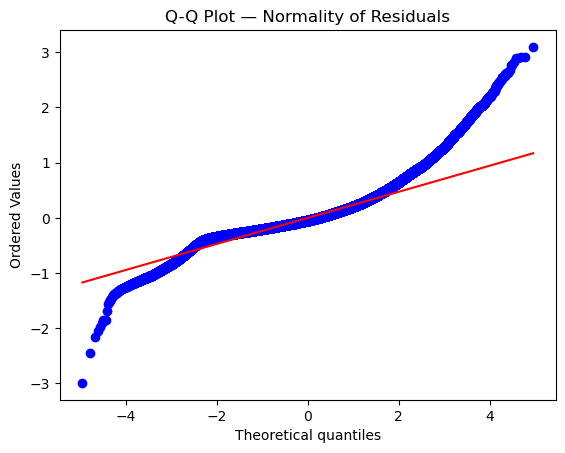

In [7]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(model.resid, plot=plt)
plt.title('Q-Q Plot — Normality of Residuals')
plt.show()

## Probability Calculation

In [8]:
dropoff_per_hour = con.sql("""
    SELECT 
        HOUR(dropoff_datetime) AS hour_dropoff,
        SUM(CASE WHEN DOLocationID = 132 THEN 1 ELSE 0 END) AS JFK_dropoffs,
        SUM(CASE WHEN DOLocationID = 138 THEN 1 ELSE 0 END) AS LGA_dropoffs,
        SUM(CASE WHEN DOLocationID = 1   THEN 1 ELSE 0 END) AS EWR_dropoffs
    FROM read_parquet(['2024/*.parquet', '2025/*.parquet'])
    WHERE trip_time BETWEEN 120 AND 7200
    AND driver_pay > 5
    GROUP BY hour_dropoff
    ORDER BY hour_dropoff
""").df()

pickups_per_hour = con.sql("""
    SELECT
        HOUR(pickup_datetime) AS hour_pickup,
        SUM(CASE WHEN PULocationID = 132 THEN 1 ELSE 0 END) AS JFK_pickups,
        SUM(CASE WHEN PULocationID = 138 THEN 1 ELSE 0 END) AS LGA_pickups,
        SUM(CASE WHEN PULocationID = 1   THEN 1 ELSE 0 END) AS EWR_pickups
    FROM read_parquet(['2024/*.parquet', '2025/*.parquet'])
    WHERE trip_time BETWEEN 120 AND 7200
    AND driver_pay > 5
    GROUP BY hour_pickup
    ORDER BY hour_pickup
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [10]:
JFK_ratio = pickups_per_hour['JFK_pickups'] / dropoff_per_hour['JFK_dropoffs']

JFK_return_prob = pd.DataFrame(
    np.minimum(pickups_per_hour['JFK_pickups'] / dropoff_per_hour['JFK_dropoffs'], 1.0)
).reset_index()

JFK_return_prob.columns = ['hour', 'JFK_return_prob']

In [11]:
JFK_return_prob

,hour,JFK_return_prob
0,0,1.000000
1,1,1.000000
2,2,1.000000
3,3,0.320035
4,4,0.103798
5,5,0.174665
6,6,0.327663
7,7,0.442378
8,8,0.485202
9,9,0.473863


In [12]:
LGA_return_prob = pd.DataFrame(
    np.minimum(pickups_per_hour['LGA_pickups'] / dropoff_per_hour['LGA_dropoffs'], 1.0)
).reset_index()

LGA_return_prob.columns = ['hour', 'LGA_return_prob']

In [13]:
LGA_return_prob

,hour,LGA_return_prob
0,0,1.000000
1,1,1.000000
2,2,1.000000
3,3,0.078824
4,4,0.013616
5,5,0.010696
6,6,0.015268
7,7,0.185231
8,8,0.381483
9,9,0.643345


## Data For Simulation

In [15]:
inputs = con.sql("""
    WITH trips AS (
        SELECT
            *,
            (CASE WHEN DOLocationID = 132 THEN 1 ELSE 0 END) AS is_JFK,
            (CASE WHEN DOLocationID = 138 THEN 1 ELSE 0 END) AS is_LGA,
            (CASE WHEN DOLocationID = 1   THEN 1 ELSE 0 END) AS is_EWR
        FROM read_parquet(['2024/*.parquet', '2025/*.parquet'])
        WHERE trip_time BETWEEN 120 AND 7200
        AND driver_pay > 5
    ),
    deadhead_JFK AS (
        SELECT
            z.Borough,
            HOUR(pickup_datetime) AS hour,
            AVG(trip_time/60.0) AS avg_JFK_return_duration,
            AVG(driver_pay)     AS avg_JFK_return_pay
        FROM read_parquet(['2024/*.parquet', '2025/*.parquet'])
        JOIN zones z ON DOLocationID = z.LocationID
        WHERE PULocationID = 132
        AND trip_time BETWEEN 120 AND 7200
        AND driver_pay > 5
        GROUP BY z.Borough, hour
    ),
    deadhead_LGA AS (
        SELECT
            z.Borough,
            HOUR(pickup_datetime) AS hour,
            AVG(trip_time/60.0) AS avg_LGA_return_duration,
            AVG(driver_pay)     AS avg_LGA_return_pay
        FROM read_parquet(['2024/*.parquet', '2025/*.parquet'])
        JOIN zones z ON DOLocationID = z.LocationID
        WHERE PULocationID = 138
        AND trip_time BETWEEN 120 AND 7200
        AND driver_pay > 5
        GROUP BY z.Borough, hour
    ),
    city_trips AS (
        SELECT
            z.Borough,
            HOUR(pickup_datetime) AS hour,
            AVG(CASE WHEN is_JFK = 0 AND is_LGA = 0 AND is_EWR = 0
                THEN driver_pay END)                           AS avg_city_pay,
            AVG(CASE WHEN is_JFK = 0 AND is_LGA = 0 AND is_EWR = 0
                THEN trip_time/60.0 END)                      AS avg_city_duration,
            AVG(CASE WHEN is_JFK = 1 THEN driver_pay END)     AS avg_JFK_pay,
            AVG(CASE WHEN is_JFK = 1 THEN trip_time/60.0 END) AS avg_JFK_duration,
            AVG(CASE WHEN is_LGA = 1 THEN driver_pay END)     AS avg_LGA_pay,
            AVG(CASE WHEN is_LGA = 1 THEN trip_time/60.0 END) AS avg_LGA_duration,
            COUNT(*) AS n
        FROM trips t
        JOIN zones z ON t.PULocationID = z.LocationID
        GROUP BY z.Borough, hour
    )
    SELECT
        c.Borough,
        c.hour,
        c.avg_JFK_pay,
        c.avg_JFK_duration,
        c.avg_LGA_pay,
        c.avg_LGA_duration,
        c.avg_city_pay,
        c.avg_city_duration,
        c.n,
        d1.avg_JFK_return_duration,
        d1.avg_JFK_return_pay,
        d2.avg_LGA_return_duration,
        d2.avg_LGA_return_pay
    FROM city_trips c
    LEFT JOIN deadhead_JFK d1 ON c.Borough = d1.Borough AND c.hour = d1.hour
    LEFT JOIN deadhead_LGA d2 ON c.Borough = d2.Borough AND c.hour = d2.hour
    ORDER BY c.Borough, c.hour
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [16]:
inputs['Borough'] = inputs['Borough'].astype(str)
inputs = inputs[~inputs['Borough'].isin(['None', 'Unknown', 'EWR'])]

In [17]:
final_derivs = con.sql(""" SELECT * 
                            FROM inputs i 
                            JOIN JFK_return_prob j 
                            ON i.hour = j.hour
                            JOIN LGA_return_prob l 
                            ON i.hour = l.hour
                        
""").df()

In [18]:
final_derivs.to_csv('final_derivs.csv', index=False)